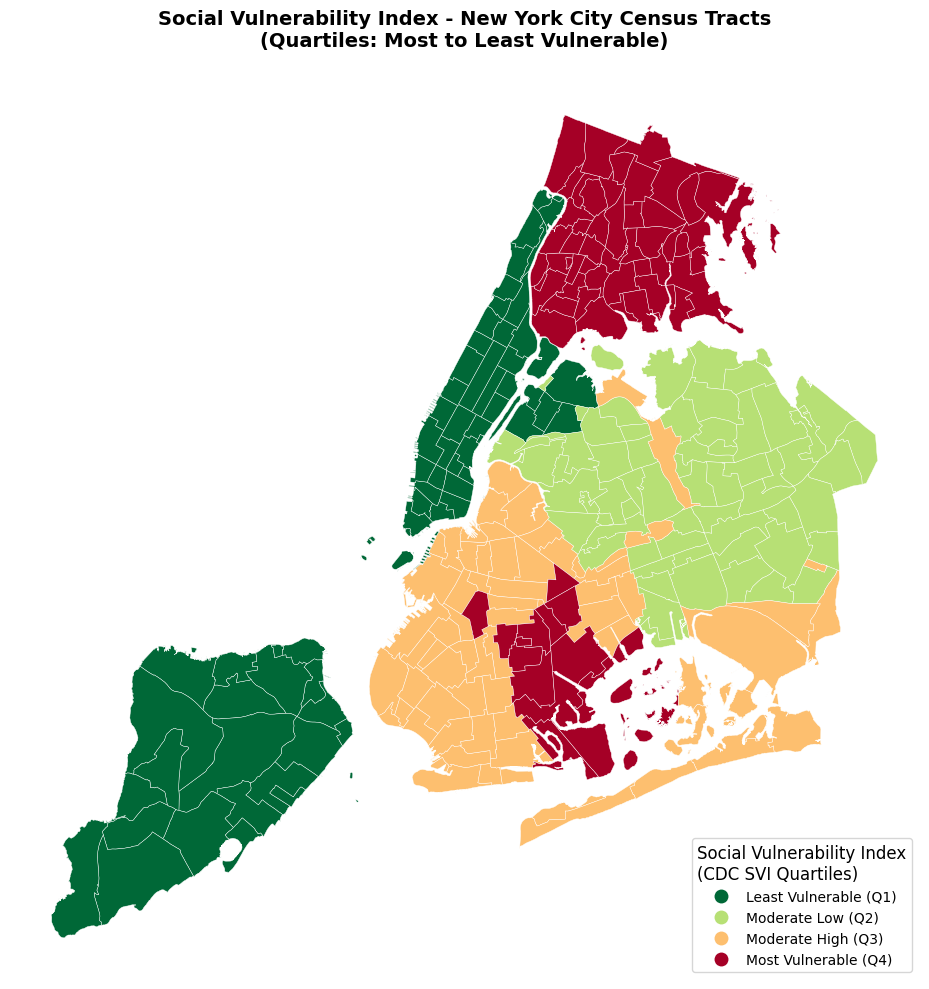


SVI Quartile Summary:
svi_quartile
Least Vulnerable (Q1)    66
Moderate Low (Q2)        65
Moderate High (Q3)       65
Most Vulnerable (Q4)     66
Name: count, dtype: int64

SVI (rpl_themes) Range by Quartile:
  Least Vulnerable (Q1): 0.431 - 0.645
  Moderate Low (Q2): 0.645 - 0.645
  Moderate High (Q3): 0.645 - 0.692
  Most Vulnerable (Q4): 0.692 - 0.890


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Load the geographic data with SVI
gdf = gpd.read_file('Data/Processed/neighborhoods_chvi.gpkg')

# Create quartiles based on SVI (rpl_themes - CDC Social Vulnerability Index)
# Higher values = more vulnerable
# Use rank-based binning to handle duplicate values
gdf['svi_rank'] = gdf['rpl_themes'].rank(method='first')
quartile_bins = [0, gdf['svi_rank'].quantile(0.25), gdf['svi_rank'].quantile(0.5), gdf['svi_rank'].quantile(0.75), gdf['svi_rank'].max() + 1]
gdf['svi_quartile'] = pd.cut(gdf['svi_rank'], bins=quartile_bins, labels=['Least Vulnerable (Q1)', 'Moderate Low (Q2)', 'Moderate High (Q3)', 'Most Vulnerable (Q4)'], include_lowest=True)

# Create the map
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the census tracts colored by SVI quartile
gdf.plot(column='svi_quartile', 
         categorical=True,
         cmap='RdYlGn_r',  # Red = High vulnerability, Green = Low vulnerability
         legend=True,
         legend_kwds={'title': 'Social Vulnerability Index\n(CDC SVI Quartiles)', 
                      'loc': 'lower right',
                      'fontsize': 10,
                      'title_fontsize': 12},
         edgecolor='white',
         linewidth=0.3,
         ax=ax)

# Remove axes for clean map
ax.set_axis_off()

# Add title
ax.set_title('Social Vulnerability Index - New York City Census Tracts\n(Quartiles: Most to Least Vulnerable)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()

plt.savefig("Outputs/Figures/social_vulnerability_map.png", 
            dpi=300, 
            bbox_inches="tight")

plt.show()

# Print summary statistics
print("\nSVI Quartile Summary:")
print(gdf['svi_quartile'].value_counts().sort_index())

print("\nSVI (rpl_themes) Range by Quartile:")
for q in ['Least Vulnerable (Q1)', 'Moderate Low (Q2)', 'Moderate High (Q3)', 'Most Vulnerable (Q4)']:
    subset = gdf[gdf['svi_quartile'] == q]['rpl_themes']
    print(f"  {q}: {subset.min():.3f} - {subset.max():.3f}")

